In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [3]:
def compute_IGs(imbalances):
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors, alphas_max

def compute_indep_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    print(IGs_vs_alpha.shape)
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs_vs_alpha[:,np.arange(n_eps),alphas_max], alphas

def compute_t_stat(values, errors):
    t = +values
    mask = errors != 0
    t[mask] /= errors[mask]
    return t

In [4]:
t_19 = 3.579 # threshold of one-tailed t statistics for 19 dof and p=0.001

## 1) Original alphas (grid of 50 points, [0, 0.25] for Rossler, [0, 0.3] for Lorenz, [0, 1.5 for Lorenz 96])
### Rossler, identical

In [8]:
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 30, 50)
(20, 30, 50)
(20, 30, 50)
(20, 30, 50)


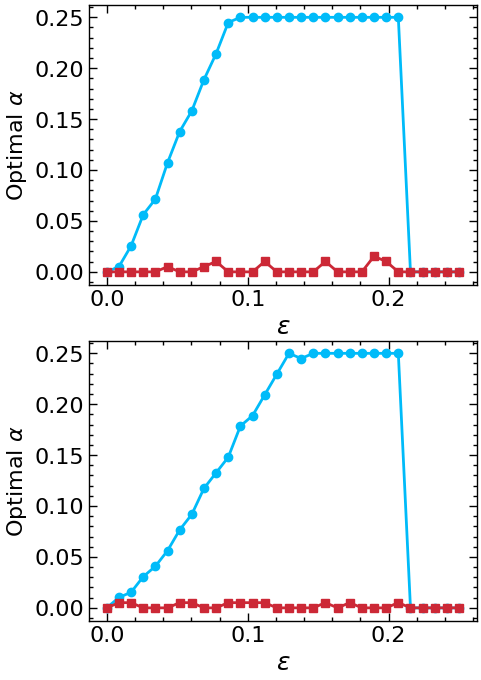

In [12]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $")
ax[0].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $")
ax[1].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[1].axes.xaxis.set_ticklabels([])

plt.savefig("./figures_alpha/rossler_id.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Rossler, different

In [13]:
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 30, 50)
(20, 30, 50)
(20, 30, 50)
(20, 30, 50)


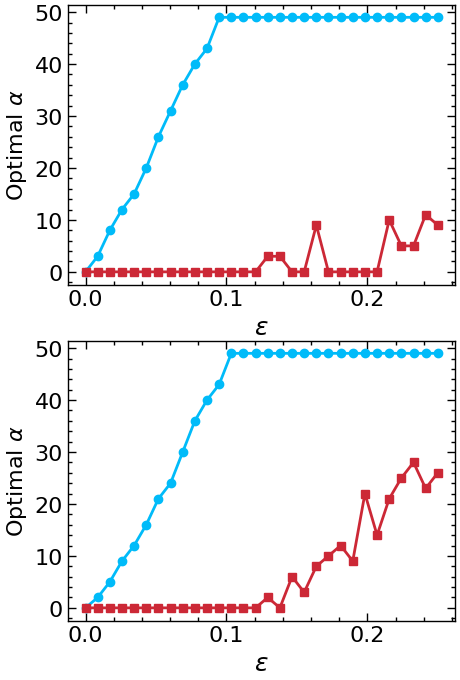

In [14]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $")
ax[0].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $")
ax[1].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[1].axes.xaxis.set_ticklabels([])

plt.savefig("./figures_alpha/rossler_diff.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz

In [17]:
epsilons = np.linspace(0.,0.3,31)
alphas = np.linspace(0.,0.3,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 31, 50)
(20, 31, 50)
(20, 31, 50)
(20, 31, 50)


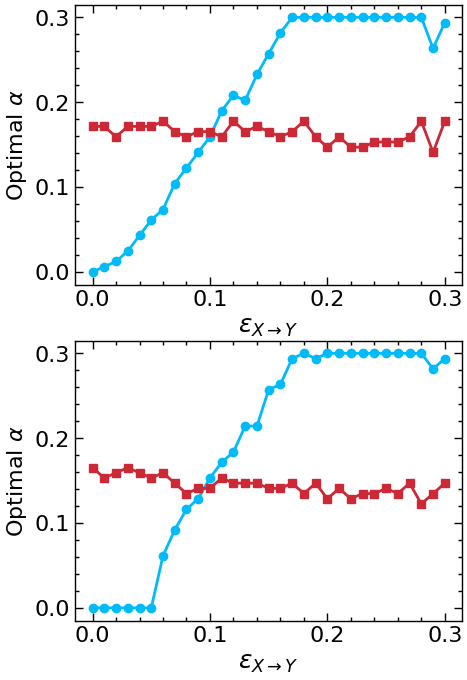

In [18]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
ax[0].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=18)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
ax[1].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=18)
#ax[1].axes.xaxis.set_ticklabels([])

plt.savefig("./figures_alpha/lorenz.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz 96

In [4]:
epsilons = np.linspace(0.,1.5,31)
alphas = np.linspace(0.,1.5,50) # for IG
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 31, 50)
(20, 31, 50)
(20, 31, 50)
(20, 31, 50)


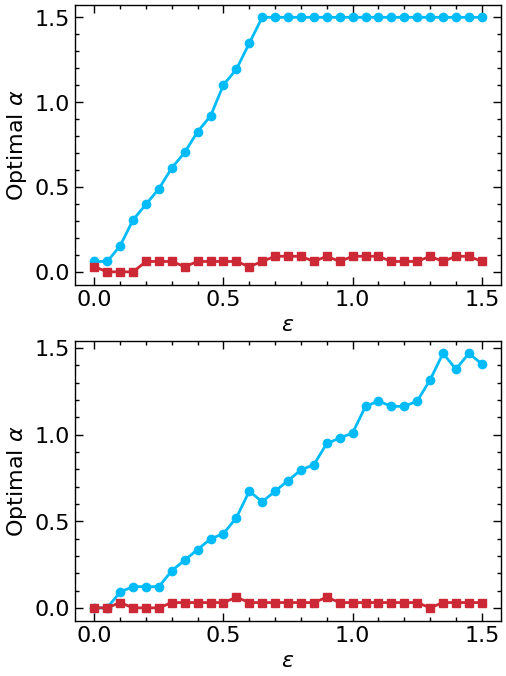

In [5]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5.5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
#ax[1].axes.xaxis.set_ticklabels([])

plt.savefig("./figures_alpha/lorenz96.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

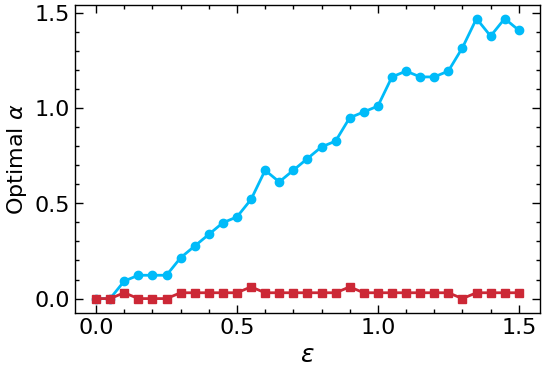

In [9]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,1,figsize=(6,4))

ax.plot(epsilons, alphas[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax.plot(epsilons, alphas[alphas_Y_to_X_emb], 's-', color=colors[1])
ax.set(ylabel="Optimal $\\alpha $")
ax.set_xlabel("$\\varepsilon$", fontsize=18)


plt.savefig("./figures_alpha/lorenz96_final.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

## 2) More alphas (grid of 300 points, [0, 1.5] forall piars of systems)
### Rossler, identical

In [10]:
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50) # for IG
alphas_more = np.linspace(0.,1.5,300)
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas_more)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas_more))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_id/seed{seed}_morealphas.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 30, 50)
(20, 30, 50)
(20, 30, 300)
(20, 30, 300)


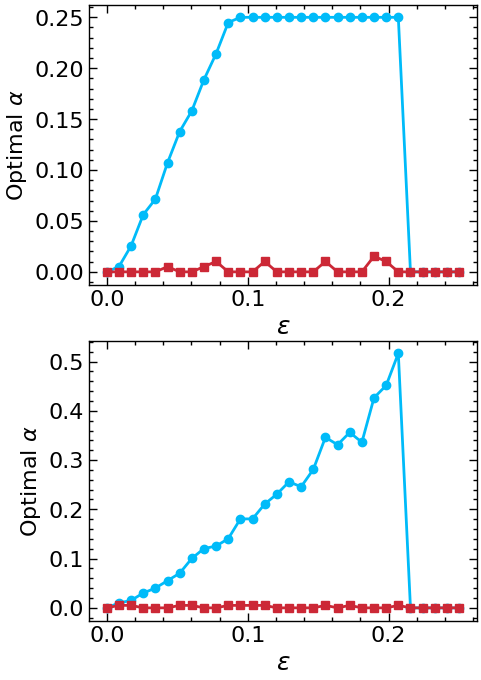

In [12]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $")
ax[0].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas_more[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas_more[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $")
ax[1].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[1].axes.xaxis.set_ticklabels([])

#plt.savefig("./figures_alpha/rossler_id.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Rossler, different

In [13]:
epsilons = np.linspace(0.,0.25,30)
alphas = np.linspace(0.,0.25,50) # for IG
alphas_more = np.linspace(0.,1.5,300)
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas_more)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas_more))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_diff/seed{seed}_morealphas.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 30, 50)
(20, 30, 50)
(20, 30, 300)
(20, 30, 300)


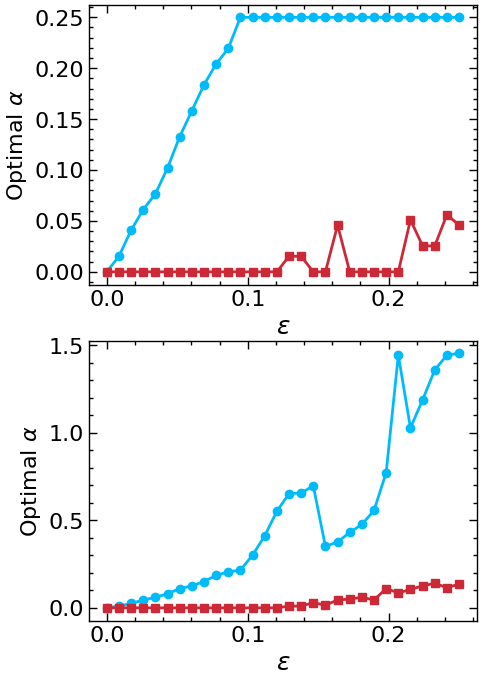

In [14]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $")
ax[0].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas_more[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas_more[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $")
ax[1].set_xlabel("$\\varepsilon$", fontsize=18)
#ax[1].axes.xaxis.set_ticklabels([])

#plt.savefig("./figures_alpha/rossler_diff.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Lorenz

In [24]:
epsilons = np.linspace(0.,0.3,31)
alphas = np.linspace(0.,0.3,50) # for IG
alphas_more = np.linspace(0.,1.5,300)
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas_more)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas_more))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz/seed{seed}_morealphas.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 31, 50)
(20, 31, 50)
(20, 31, 300)
(20, 31, 300)


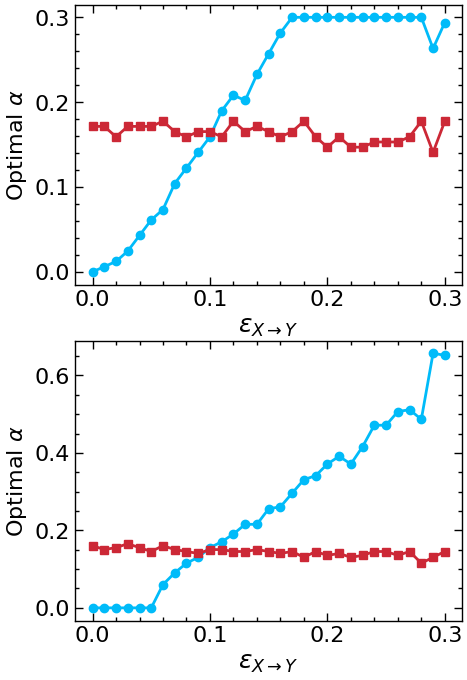

In [16]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
ax[0].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=18)
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas_more[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas_more[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
ax[1].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=18)
#ax[1].axes.xaxis.set_ticklabels([])

#plt.savefig("./figures_alpha/lorenz.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

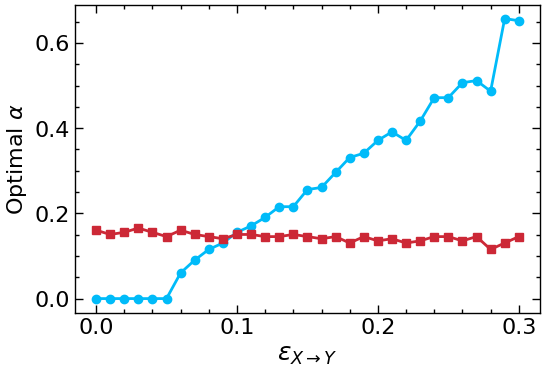

In [25]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,1,figsize=(6,4))

ax.plot(epsilons, alphas_more[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax.plot(epsilons, alphas_more[alphas_Y_to_X_emb], 's-', color=colors[1])
ax.set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
ax.set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=18)

plt.savefig("./figures_alpha/lorenz_embeddings_morealphas.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Lorenz 96

In [26]:
epsilons = np.linspace(0.,1.5,31)
alphas = np.linspace(0.,1.5,50) # for IG
alphas_more = np.linspace(0.,1.5,300)
nseeds = 20

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err, alphas_X_to_Y = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err, alphas_Y_to_X = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas_more)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas_more))) 
for iseed, seed in enumerate(range(1,21)):#range(nseeds):
    info_imbalances_X_to_Y_emb[iseed], info_imbalances_Y_to_X_emb[iseed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}_morealphas.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, alphas_X_to_Y_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, alphas_Y_to_X_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

(20, 31, 50)
(20, 31, 50)
(20, 31, 300)
(20, 31, 300)


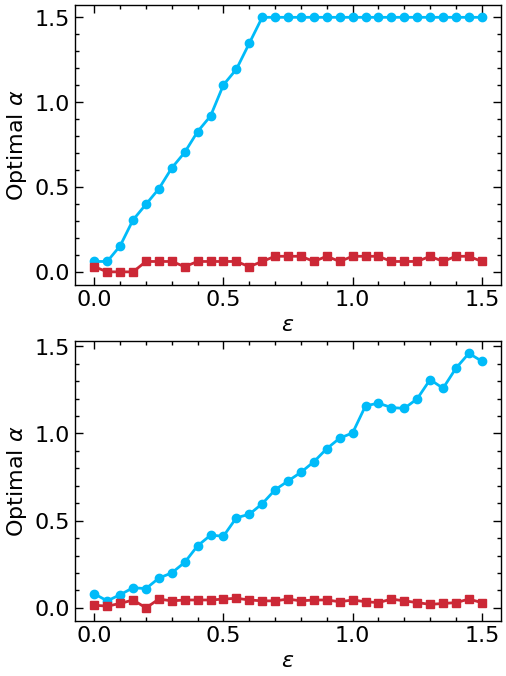

In [21]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(5.5,8))

ax[0].plot(epsilons, alphas[alphas_X_to_Y], 'o-', color=colors[0])
ax[0].plot(epsilons, alphas[alphas_Y_to_X], 's-', color=colors[1])
ax[0].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
#ax[0].axes.xaxis.set_ticklabels([])

ax[1].plot(epsilons, alphas_more[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax[1].plot(epsilons, alphas_more[alphas_Y_to_X_emb], 's-', color=colors[1])
ax[1].set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
#ax[1].axes.xaxis.set_ticklabels([])

#plt.savefig("./figures_alpha/lorenz96.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

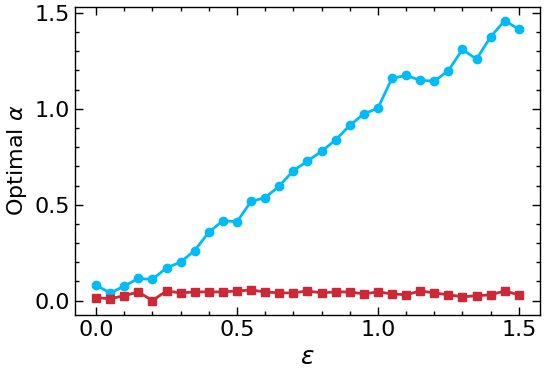

In [28]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(1,1,figsize=(6,4))

ax.plot(epsilons, alphas_more[alphas_X_to_Y_emb], 'o-', color=colors[0])
ax.plot(epsilons, alphas_more[alphas_Y_to_X_emb], 's-', color=colors[1])
ax.set(ylabel="Optimal $\\alpha $", xlabel="$\\varepsilon$")
ax.set_xlabel("$\\varepsilon$", fontsize=18)

plt.savefig("./figures_alpha/lorenz96_embeddings_morealphas.pdf", dpi=300, bbox_inches='tight')
plt.show()